<a href="https://colab.research.google.com/github/Sujal9858/SujalGit/blob/main/labb4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#Supervised Learning: Binary Classifiers Template
#Glen Mason
#Week 5 Decision Tree Classifier

In [8]:
#Declare Reference to General Libraries
import pandas as pd #Used to manipulate data sets (derived from PaNel DAta) pd is a short alias.
import numpy as np #Used to work with Arrays (e.g. useful in manual I/O validation)
import matplotlib.pyplot as plt #Used to generate statistical illustrations e.g. graphs
import seaborn as sns #A more sophisticated version of matplotlib
#Import Special Data Analysis Packages
from sklearn.model_selection import train_test_split #Used to split Data Set
from sklearn.tree import DecisionTreeClassifier #Selected Modelling Algorithim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


Rows Columns
(54035, 9)
   cap-diameter  cap-shape  gill-attachment  gill-color  stem-height  \
0          1372          2                2          10     3.807467   
1          1461          2                2          10     3.807467   
2          1371          2                2          10     3.612496   
3          1261          6                2          10     3.787572   
4          1305          6                2          10     3.711971   

   stem-width  stem-color    season  class  
0        1545          11  1.804273      1  
1        1557          11  1.804273      1  
2        1566          11  1.804273      1  
3        1566          11  1.804273      1  
4        1464          11  0.943195      1  

 class
1    29675
0    24360
Name: count, dtype: int64


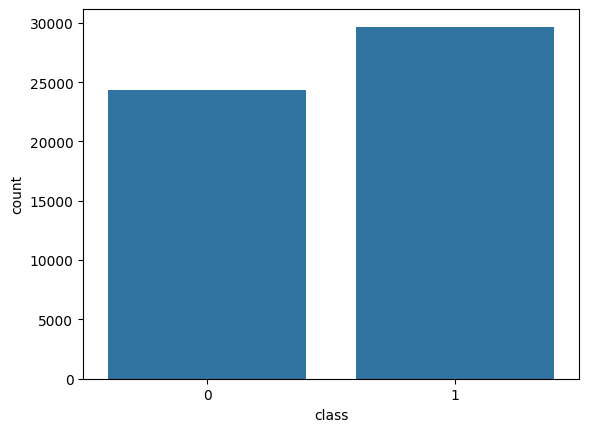

<Figure size 640x480 with 0 Axes>

In [11]:
#Read and Display Data Set
#First, read in CSV file and assign it to a variable called "data"
data = pd.read_csv('poisonous_or_edible_mushrooms.csv')
#Second, display maximum rows and columns
print('\nRows Columns') #indicates rows and columns
print(data.shape) #gets the number rows and columns of data
pd.set_option('display.max_columns',None) #optional setting to show all feature columns
#Third, display first 5 x rows to check data
print(data.head(5))
#Select the last column (assuming the last column is the class)
last_column = data.iloc[:, -1] # Using iloc to select the last column
#Count occurrences of 0's and 1's
value_counts = last_column.value_counts()
#Print the counts and check for class imbalance
print('\n',value_counts)
#------EXTRA DATA SCIENCE INFO--------
#Display grahical Bar Chart of classification balance
sns.countplot(x='class', data=data)
plt.show()
plt.clf()

Axes(0.125,0.11;0.62x0.77)


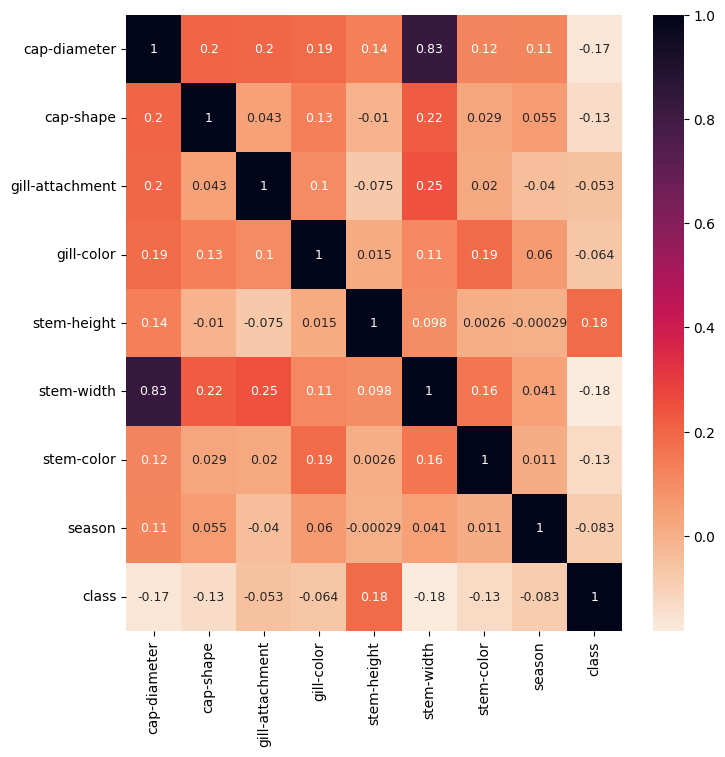

In [12]:
#Display Feature Relations of Data Set
plt.figure(figsize=(8,8)) #Adjust width and height
print(sns.heatmap(data.corr(),annot=True, annot_kws={"size":9}, cmap = sns.cm.rocket_r))


In [13]:
#Declare X and Y Variables and Split the DataSet into Train and Test sections
X=data.drop(['class'],axis=1).values #X variables = all columns except last one
#Declare last column to be the dependednt Y variable
y=data['class']
#Split Data Set 70% Training and 30% Testing. Initial data shuffle set to Zero.
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.7,test_size = 0.3, random_state=0)

In [21]:
#Create and Test the Model
#First declare a new model
classifier_model = DecisionTreeClassifier(max_depth=4,min_samples_leaf=2,min_samples_split=3)
#Second Train (fit) the model from the training data
classifier_model.fit(X_train,y_train)
#Fourth make some predictions
y_pred = classifier_model.predict(X_test)
# print('\nTest Data Model Predictions:', y_pred)

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("Confusion Matrix (Before):")
print(confusion_matrix(y_test, y_pred))

print("\nMetrics (Before):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix (Before):
[[5249 2056]
 [3082 5824]]

Metrics (Before):
Accuracy: 0.6830547159336253
Precision: 0.7390862944162436
Recall: 0.6539411632607232
F1 Score: 0.6939115929941618


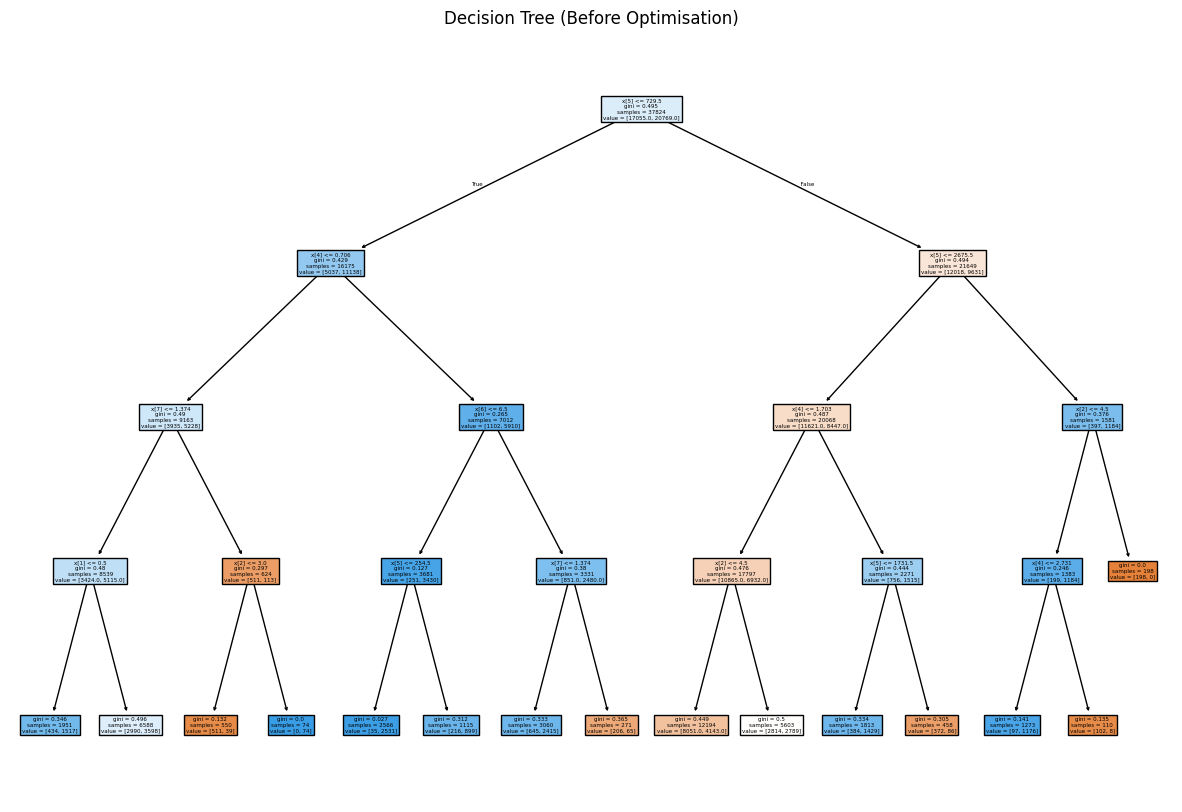

In [25]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(classifier_model, filled=True)
plt.title("Decision Tree (Before Optimisation)")
plt.show()

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3,4,5,6],
    'min_samples_split': [2,3,4],
    'min_samples_leaf': [1,2,3]
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [27]:
best_params = grid.best_params_

model_opt = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf']
)

model_opt.fit(X_train, y_train)
y_pred_opt = model_opt.predict(X_test)

In [28]:
print("Confusion Matrix (After):")
print(confusion_matrix(y_test, y_pred_opt))

print("\nMetrics (After):")
print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("Precision:", precision_score(y_test, y_pred_opt))
print("Recall:", recall_score(y_test, y_pred_opt))
print("F1 Score:", f1_score(y_test, y_pred_opt))

Confusion Matrix (After):
[[4336 2969]
 [ 897 8009]]

Metrics (After):
Accuracy: 0.7615199555857134
Precision: 0.7295500091091274
Recall: 0.8992813833370761
F1 Score: 0.8055723194528264


In [23]:
#Evaluate the Model: Display Confusion Matrix and Performance Metrics
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


Confusion Matrix:
 [[5249 2056]
 [3082 5824]]



Evaluation Metrics:
Accuracy: 0.68
Precision: 0.74
Recall: 0.65
F1 Score: 0.69


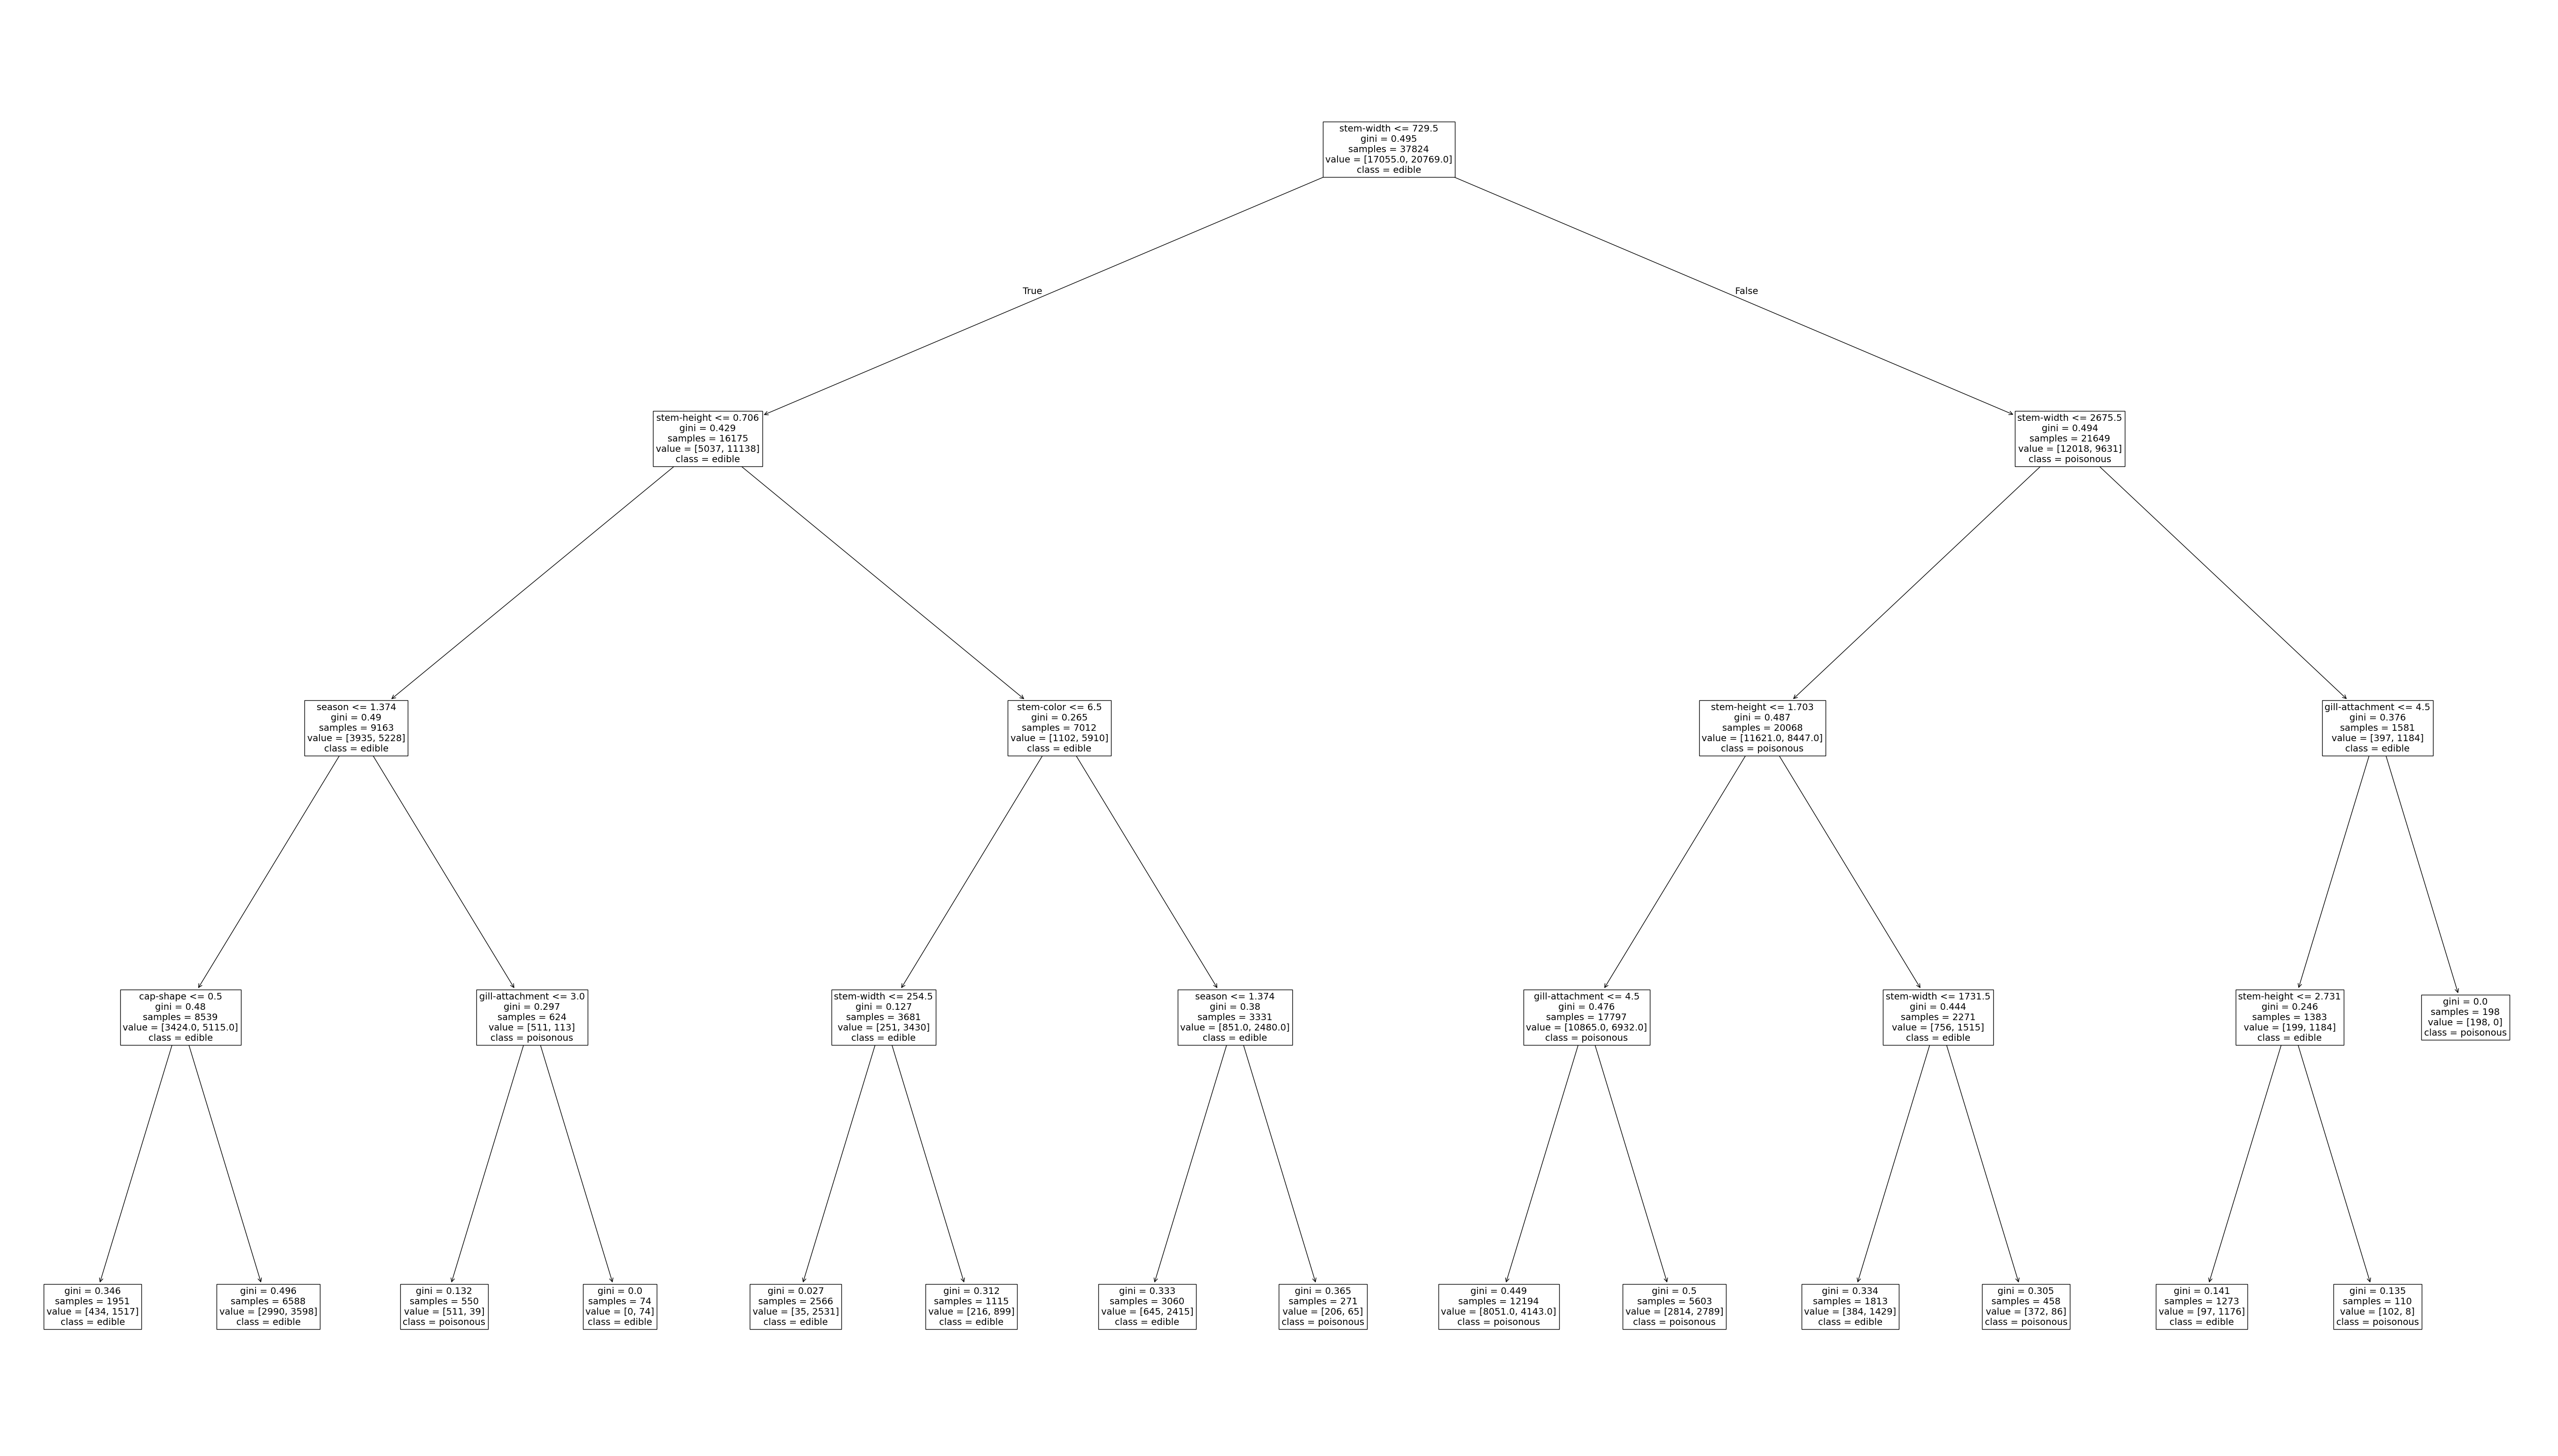

In [16]:
# Display the performance metrics
print("\nEvaluation Metrics:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
from sklearn.tree import plot_tree
plt.figure('Decsion Tree', figsize=(70, 40))
plot_tree(classifier_model, fontsize=14, feature_names=data.columns, class_names=['poisonous', 'edible'])
plt.show()

In [19]:
#Optimising the Model for better metrics
from sklearn.model_selection import GridSearchCV #Used for Optimisation
param_grid = {
'max_depth':[5, 10, 20, 30],
'min_samples_split': [2, 3, 4, 5],
'min_samples_leaf': [1, 2, 3, 4]
}
grid = GridSearchCV(DecisionTreeClassifier(),param_grid,verbose=3, cv=5)
grid.fit(X_train,y_train)
grid.best_params_
#Display best parameters
print("\n Optimised Parameters: ")
print(grid.best_params_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV 1/5] END max_depth=5, min_samples_leaf=1, min_samples_split=2;, score=0.694 total time=   0.2s
[CV 2/5] END max_depth=5, min_samples_leaf=1, min_samples_split=2;, score=0.718 total time=   0.1s
[CV 3/5] END max_depth=5, min_samples_leaf=1, min_samples_split=2;, score=0.711 total time=   0.2s
[CV 4/5] END max_depth=5, min_samples_leaf=1, min_samples_split=2;, score=0.708 total time=   0.1s
[CV 5/5] END max_depth=5, min_samples_leaf=1, min_samples_split=2;, score=0.713 total time=   0.2s
[CV 1/5] END max_depth=5, min_samples_leaf=1, min_samples_split=3;, score=0.694 total time=   0.1s
[CV 2/5] END max_depth=5, min_samples_leaf=1, min_samples_split=3;, score=0.718 total time=   0.2s
[CV 3/5] END max_depth=5, min_samples_leaf=1, min_samples_split=3;, score=0.711 total time=   0.2s
[CV 4/5] END max_depth=5, min_samples_leaf=1, min_samples_split=3;, score=0.708 total time=   0.2s
[CV 5/5] END max_depth=5, min_samples_leaf=1, m

In [29]:
best_params = grid.best_params_

model_opt = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf']
)

model_opt.fit(X_train, y_train)
y_pred_opt = model_opt.predict(X_test)

In [30]:
print("Confusion Matrix (After):")
print(confusion_matrix(y_test, y_pred_opt))

print("\nMetrics (After):")
print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("Precision:", precision_score(y_test, y_pred_opt))
print("Recall:", recall_score(y_test, y_pred_opt))
print("F1 Score:", f1_score(y_test, y_pred_opt))

Confusion Matrix (After):
[[4336 2969]
 [ 897 8009]]

Metrics (After):
Accuracy: 0.7615199555857134
Precision: 0.7295500091091274
Recall: 0.8992813833370761
F1 Score: 0.8055723194528264
